In [7]:
import os, random, math
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit.primitives import Estimator
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

from sklearn.model_selection import train_test_split


In [8]:
#max_in_class = 200
#train_part = 0.5
#noise = 0.1
batch_size = 128

epochs = 30
initial_lr = 0.002

device = "cpu"

In [9]:
fashion_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

dataset_train = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=True, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)
dataset_test = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=False, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)

train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=1, shuffle=True)

print(len(train_dataloader.dataset), len(test_dataloader.dataset))

# Визуализация с подписью класса
plt.imshow(dataset_train[0][0].squeeze(), cmap='gray')
plt.title(f"Class: {fashion_classes[dataset_train[0][1]]}")
plt.show()

#for batch in dataloader:
#    print("Batch Data:", batch[0])  
#    print("Batch Labels:", batch[1])

60000 10000


C:\Users\maxsl\AppData\Local\Temp\ipykernel_27544\2496410291.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
plt.imshow(dataset_train[0][0].reshape(28, 28), cmap='gray')#черно-белое изображение

In [11]:
pd.set_option('display.max_columns', 28)
pd.DataFrame(dataset_train[0][0].reshape(28, 28))#изображение в виде матрицы

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.000000,0.050980,0.286275,0.000000,0.000000,0.003922,0.015686,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011765,0.000000,0.141176,0.533333,0.498039,0.243137,0.211765,0.000000,0.000000,0.000000,0.003922,0.011765,0.015686,0.000000,0.000000,0.011765
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.000000,0.400000,0.800000,0.690196,0.525490,0.564706,0.482353,0.090196,0.000000,0.000000,0.000000,0.000000,0.047059,0.039216,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.607843,0.925490,0.811765,0.698039,0.419608,0.611765,0.631373,0.427451,0.250980,0.090196,0.301961,0.509804,0.282353,0.058824
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.270588,0.811765,0.874510,0.854902,0.847059,0.847059,0.639216,0.498039,0.474510,0.478431,0.572549,0.552941,0.345098,0.674510,0.258824
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.003922,0.000000,0.784314,0.909804,0.909804,0.913725,0.898039,0.874510,0.874510,0.843137,0.835294,0.643137,0.498039,0.482353,0.768627,0.898039,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.717647,0.882353,0.847059,0.874510,0.894118,0.921569,0.890196,0.878431,0.870588,0.878431,0.866667,0.874510,0.960784,0.678431,0.000000


In [12]:
MP1 = nn.MaxPool2d(kernel_size=2, stride= 2)
pd.set_option('display.max_columns', 14)
tmp_MP1 = MP1(dataset_train[0][0])
pd.DataFrame(tmp_MP1.reshape(14, 14))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.050980,0.286275,0.003922,0.015686,0.000000,0.003922,0.003922
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.800000,0.690196,0.564706,0.090196,0.011765,0.047059,0.039216
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.270588,0.925490,0.854902,0.847059,0.631373,0.572549,0.552941,0.674510
4,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.784314,0.909804,0.913725,0.921569,0.878431,0.878431,0.960784,0.898039
5,0.000000,0.000000,0.000000,0.000000,0.003922,0.011765,0.858824,0.894118,0.854902,0.890196,0.854902,0.878431,0.952941,0.819608
6,0.000000,0.000000,0.000000,0.000000,0.015686,0.023529,0.956863,0.901961,0.941176,0.909804,0.874510,0.917647,0.960784,0.654902
7,0.011765,0.015686,0.027451,0.007843,0.243137,0.800000,0.929412,0.874510,0.870588,0.870588,0.878431,0.898039,1.000000,0.623529
8,0.223529,0.815686,0.878431,0.878431,0.894118,0.870588,0.886275,0.960784,0.901961,1.000000,0.917647,0.980392,0.933333,0.964706
9,0.913725,0.894118,0.898039,0.917647,0.976471,0.862745,0.945098,1.000000,0.898039,0.858824,0.866667,0.874510,0.894118,0.898039


In [13]:
pd.set_option('display.max_columns', 7)
pd.DataFrame(MP1(tmp_MP1).reshape(7, 7))

,0,1,2,3,4,5,6
0,0.000000,0.000000,0.000000,0.050980,0.286275,0.015686,0.003922
1,0.000000,0.000000,0.003922,0.925490,0.854902,0.631373,0.674510
2,0.000000,0.000000,0.011765,0.909804,0.921569,0.878431,0.960784
3,0.015686,0.027451,0.800000,0.956863,0.941176,0.917647,1.000000
4,0.913725,0.917647,0.976471,1.000000,1.000000,0.980392,0.964706
5,0.858824,0.882353,0.847059,0.941176,0.960784,0.870588,0.901961
6,0.007843,0.929412,0.964706,0.956863,0.749020,0.709804,0.388235


In [14]:
MP2 = nn.MaxPool2d(kernel_size=2, stride= 1)
pd.set_option('display.max_columns', 13)
pd.DataFrame(MP2(tmp_MP1).reshape(13, 13))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.050980,0.286275,0.286275,0.015686,0.015686,0.003922,0.003922
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.800000,0.800000,0.690196,0.564706,0.090196,0.047059,0.047059
2,0.000000,0.000000,0.000000,0.000000,0.003922,0.270588,0.925490,0.925490,0.854902,0.847059,0.631373,0.572549,0.674510
3,0.000000,0.000000,0.000000,0.003922,0.003922,0.784314,0.925490,0.925490,0.921569,0.921569,0.878431,0.960784,0.960784
4,0.000000,0.000000,0.000000,0.003922,0.011765,0.858824,0.909804,0.913725,0.921569,0.921569,0.878431,0.960784,0.960784
5,0.000000,0.000000,0.000000,0.015686,0.023529,0.956863,0.956863,0.941176,0.941176,0.909804,0.917647,0.960784,0.960784
6,0.015686,0.027451,0.027451,0.243137,0.800000,0.956863,0.956863,0.941176,0.941176,0.909804,0.917647,1.000000,1.000000
7,0.815686,0.878431,0.878431,0.894118,0.894118,0.929412,0.960784,0.960784,1.000000,1.000000,0.980392,1.000000,1.000000
8,0.913725,0.898039,0.917647,0.976471,0.976471,0.945098,1.000000,1.000000,1.000000,1.000000,0.980392,0.980392,0.964706
9,0.913725,0.898039,0.917647,0.976471,0.976471,0.945098,1.000000,1.000000,0.960784,0.937255,0.874510,0.894118,0.901961


In [ ]:
class QuantumSEBlock(nn.Module):
    """Квантовый Squeeze-and-Excitation блок."""
    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        self.n_qubits = max(2, min(channels // reduction, 4))
        self.fc1 = nn.Linear(channels, self.n_qubits, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.qnn = self._build_quantum_qnn(self.n_qubits)
        self.fc2 = nn.Linear(self.n_qubits, channels, bias=False)
        self.sigmoid = nn.Sigmoid()

    def _build_quantum_qnn(self, n_qubits: int) -> nn.Module:
        feature_map = ZZFeatureMap(n_qubits, reps=1)
        input_params = list(feature_map.parameters)
        ansatz = RealAmplitudes(n_qubits, reps=1, entanglement="linear")
        qc = feature_map.compose(ansatz)

        observables = []
        for i in range(n_qubits):
            label = ''.join('Z' if i == j else 'I' for j in range(n_qubits))
            observables.append(SparsePauliOp(Pauli(label)))

        qnn = EstimatorQNN(
            circuit=qc,
            observables=observables,
            input_params=input_params,
            weight_params=ansatz.parameters,
            estimator=Estimator()
        )
        return TorchConnector(qnn)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()
        y = x.mean(dim=[2, 3])                    # Squeeze
        y = self.fc1(y)
        y = self.relu(y)
        y = self.qnn(y)
        y = self.fc2(y)
        y = self.sigmoid(y)                       # Excitation
        y = y.view(b, c, 1, 1)
        return x * y                              # Scale


In [16]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.se1   = QuantumSEBlock(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.se2   = QuantumSEBlock(64)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.se1(x)              
        x = self.pool(x)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.se2(x)            
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [17]:
model = SimpleNN()
summary(model, (1, 28, 28), batch_size, device = device)
print(model)

TypeError: ZZFeatureMap.__init__() got an unexpected keyword argument 'input_params'

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [ ]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 84.3%, Avg loss: 1.618108 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 87.1%, Avg loss: 1.589896 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 87.1%, Avg loss: 1.589551 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 87.2%, Avg loss: 1.588935 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 87.9%, Avg loss: 1.581292 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 88.5%, Avg loss: 1.575939 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 89.6%, Avg loss: 1.564571 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 88.5%, Avg loss: 1.575073 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 89.2%, Avg loss: 1.568615 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 89.7%, Avg loss: 1.564360 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 89.1%, Avg los

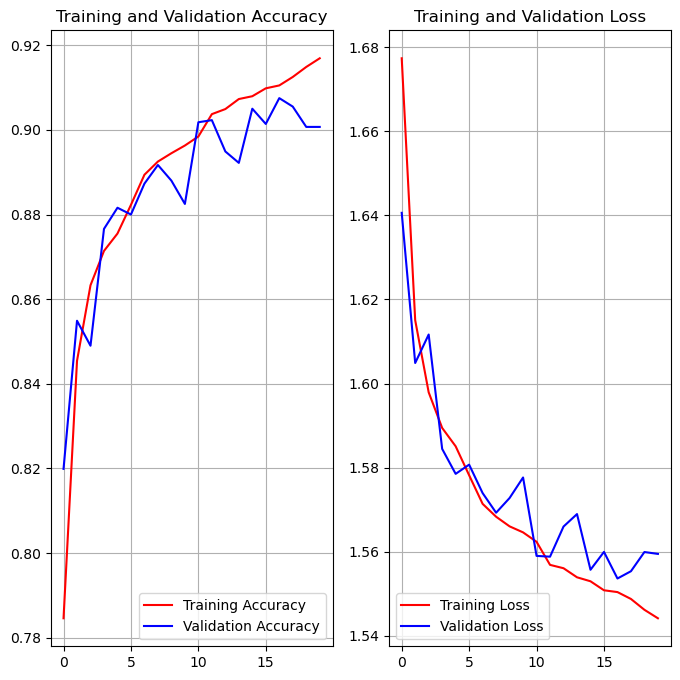

In [ ]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [ ]:
model.eval()
test_dataloader
predictions = torch.LongTensor().to(device)
cmt = torch.zeros(10, 10, dtype=torch.int32)#Матрица ошибок
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X.to(device))
        predictions = preds.argmax(dim=1)
        cmt[y, predictions] += 1
    

In [ ]:
pd.set_option('display.max_columns', 10)
pd.DataFrame(cmt.reshape(10, 10))#строка истинное значение, столбец предсказанное

,0,1,2,3,4,5,6,7,8,9
0,910,0,13,30,1,1,37,0,8,0
1,1,980,0,16,1,0,0,0,2,0
2,30,1,900,10,23,0,34,0,2,0
3,15,8,9,934,15,0,18,0,1,0
4,2,2,153,36,745,0,59,0,3,0
5,0,0,0,0,0,982,0,15,0,3
6,177,1,83,32,55,0,640,0,12,0
7,0,0,0,0,0,8,0,982,1,9
8,2,1,1,6,2,1,0,3,984,0
9,0,0,0,0,0,4,0,45,1,950
